<a href="https://colab.research.google.com/github/clee2026/MSDS_498/blob/main/capstone/finding_larger/notebook_4_v3_operational_clustering_trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4 v3 - Operational Clustering, Hotspots, and Trend Analysis

1. Uses the corrected repeat complaint proxy from Notebook 2.
2. Avoids reporting tiny clusters as meaningful operational segments.
3. Clusters operational units rather than blindly over-interpreting individual records.
4. Adds trend outputs with explicit coverage warnings when the sample has limited time span.
5. Produces final-report-ready segment summaries and plots.


In [ ]:
import os
import gc
import json
import math
import time
import shutil
import zipfile
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# Upload Notebook2 output zip

In [ ]:
# USER CONFIGURATION

NOTEBOOK2_ZIP = "/content/notebook2_v3_outputs.zip"
NOTEBOOK2_DIR = Path("/content/notebook2_v3_outputs")
MODEL_READY_PATH = NOTEBOOK2_DIR / "model_ready_sample_v3.parquet"

OUTPUT_DIR = Path("/content/notebook4_v3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
MIN_CLUSTER_RECORDS_FOR_REPORT = 100
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")


In [ ]:
# LOAD NOTEBOOK 2 OUTPUT ZIP

import zipfile
import shutil
from pathlib import Path

NOTEBOOK2_ZIP = Path("/content/notebook2_v3_outputs.zip")
NOTEBOOK2_DIR = Path("/content/notebook2_v3_outputs_extracted")

print("Notebook 2 zip exists:", NOTEBOOK2_ZIP.exists())
print("Notebook 2 zip size:", NOTEBOOK2_ZIP.stat().st_size if NOTEBOOK2_ZIP.exists() else "missing")

# Validate that this is actually a zip file
if not zipfile.is_zipfile(NOTEBOOK2_ZIP):
    raise ValueError(
        f"{NOTEBOOK2_ZIP} is not a valid zip file. "
        "Recreate it in Notebook 2 using shutil.make_archive."
    )

if NOTEBOOK2_DIR.exists():
    shutil.rmtree(NOTEBOOK2_DIR)

NOTEBOOK2_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(NOTEBOOK2_ZIP, "r") as z:
    z.extractall(NOTEBOOK2_DIR)

print("Extracted Notebook 2 outputs to:", NOTEBOOK2_DIR)
print("Files found:")
for p in NOTEBOOK2_DIR.rglob("*"):
    print(p)

Notebook 2 zip exists: True
Notebook 2 zip size: 167498956
Extracted Notebook 2 outputs to: /content/notebook2_v3_outputs_extracted
Files found:
/content/notebook2_v3_outputs_extracted/transformation_rules_v3.csv
/content/notebook2_v3_outputs_extracted/repeat_key_chunks
/content/notebook2_v3_outputs_extracted/full_dataset_repeat_proxy_counts.csv
/content/notebook2_v3_outputs_extracted/notebook2_v3_manifest.json
/content/notebook2_v3_outputs_extracted/model_ready_sample_v3.parquet
/content/notebook2_v3_outputs_extracted/final_model_field_list_v3.csv
/content/notebook2_v3_outputs_extracted/repeat_proxy_sample_summary.csv
/content/notebook2_v3_outputs_extracted/analysis_ready_sample_v3.parquet
/content/notebook2_v3_outputs_extracted/repeat_key_chunks/repeat_counts_rg_0017.csv
/content/notebook2_v3_outputs_extracted/repeat_key_chunks/repeat_counts_rg_0006.csv
/content/notebook2_v3_outputs_extracted/repeat_key_chunks/repeat_counts_rg_0003.csv
/content/notebook2_v3_outputs_extracted/repeat_k

In [ ]:
ANALYSIS_READY_PATH = NOTEBOOK2_DIR / "analysis_ready_sample_v3.parquet"

if not ANALYSIS_READY_PATH.exists():
    matches = list(NOTEBOOK2_DIR.rglob("analysis_ready_sample.parquet"))
    if matches:
        ANALYSIS_READY_PATH = matches[0]
    else:
        raise FileNotFoundError(
            "Could not find analysis_ready_sample.parquet in extracted Notebook 2 outputs."
        )

print("Using:", ANALYSIS_READY_PATH)

df = pd.read_parquet(ANALYSIS_READY_PATH)

print(df.shape)
df.head()

# Ensure ZIP is treated as categorical/text.
if "zip_code" in df.columns:
    df["zip_code"] = df["zip_code"].astype(str)

# Notebook 2 created incident_zip, but it may be all UNKNOWN.
# Use zip_code as the better geographic ZIP field when available.
if "zip_code" in df.columns:
    if "incident_zip" not in df.columns:
        df["incident_zip"] = df["zip_code"]
    else:
        bad_zip = (
            df["incident_zip"].isna()
            | df["incident_zip"].astype(str).str.upper().isin(["UNKNOWN", "NAN", "NONE", ""])
        )
        df.loc[bad_zip, "incident_zip"] = df.loc[bad_zip, "zip_code"]

Using: /content/notebook2_v3_outputs_extracted/analysis_ready_sample_v3.parquet
(500000, 52)


In [ ]:
# DATA VALIDATION

required = ["complaint_type", "borough", "created_ym", "response_time_hours", "closed_same_day_flag", "repeat_complaint_proxy"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns from Notebook 2 v3: {missing}")

# Keep valid response records.
df = df[df["response_time_hours"].notna()].copy()
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
df["created_ym"] = df["created_date"].dt.to_period("M").astype(str)

print("Valid rows:", f"{len(df):,}")
print("Unique months:", df["created_ym"].nunique())


Valid rows: 487,454
Unique months: 76


In [ ]:
# OPERATIONAL UNIT TABLE
# Cluster complaint_type + borough units. This is easier to explain operationally than
# clustering millions of individual rows.

unit_cols = ["complaint_type", "borough"]
ops = (
    df.groupby(unit_cols)
    .agg(
        request_count=("complaint_type", "size"),
        avg_response_hours=("response_time_hours", "mean"),
        median_response_hours=("response_time_hours", "median"),
        p90_response_hours=("response_time_hours", lambda s: s.quantile(0.90)),
        same_day_rate=("closed_same_day_flag", "mean"),
        repeat_proxy_rate=("repeat_complaint_proxy", "mean"),
        avg_repeat_group_count=("repeat_group_count", "mean"),
    )
    .reset_index()
)

# Remove tiny operational units from clustering so they do not become misleading segments.
ops_model = ops[ops["request_count"] >= MIN_CLUSTER_RECORDS_FOR_REPORT].copy()
print("Operational units total:", len(ops))
print("Operational units used for clustering:", len(ops_model))
display(ops_model.sort_values("request_count", ascending=False).head(20))
ops.to_csv(OUTPUT_DIR / "operational_unit_summary_all.csv", index=False)
ops_model.to_csv(OUTPUT_DIR / "operational_unit_summary_modeling.csv", index=False)


Operational units total: 900
Operational units used for clustering: 374


,complaint_type,borough,request_count,avg_response_hours,median_response_hours,p90_response_hours,same_day_rate,repeat_proxy_rate,avg_repeat_group_count
368,ILLEGAL PARKING,BROOKLYN,24380,2.296012,1.014861,4.653167,0.904389,0.715094,34.254430
513,NOISE - RESIDENTIAL,BRONX,22035,15.582719,1.492778,13.884000,0.756115,0.884865,7185.592194
370,ILLEGAL PARKING,QUEENS,19794,2.839591,1.444583,6.731417,0.834546,0.677175,27.630241
323,HEAT/HOT WATER,BRONX,14071,42.584119,37.017222,81.017778,0.152868,0.889063,46.074337
514,NOISE - RESIDENTIAL,BROOKLYN,13959,2.022186,0.707222,3.246333,0.861666,0.698689,20.918977
516,NOISE - RESIDENTIAL,QUEENS,10931,8.071521,0.895833,4.322778,0.825085,0.651176,16.856097
324,HEAT/HOT WATER,BROOKLYN,10648,54.109536,46.130000,103.901778,0.110819,0.773666,18.509110
367,ILLEGAL PARKING,BRONX,10166,3.558325,1.754722,8.243750,0.851564,0.697029,14.345465
515,NOISE - RESIDENTIAL,MANHATTAN,10017,1.201189,0.618333,2.800889,0.885395,0.796346,25.427573
78,BLOCKED DRIVEWAY,QUEENS,10013,2.897610,1.516667,6.712833,0.8461,0.470888,4.349346


,k,silhouette_score
0,2,0.710616
1,3,0.480301
2,4,0.482537
3,5,0.492954
4,6,0.412805
5,7,0.420106
6,8,0.421542


Selected k: 2


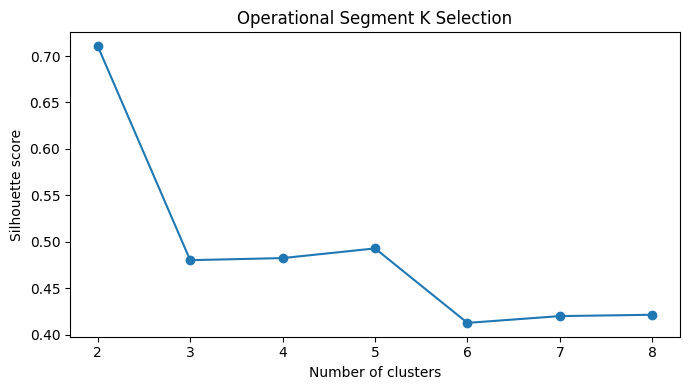

In [ ]:
# SELECT K USING SILHOUETTE

cluster_features = [
    "request_count", "avg_response_hours", "median_response_hours", "p90_response_hours",
    "same_day_rate", "repeat_proxy_rate", "avg_repeat_group_count"
]

X_ops = ops_model[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0)
X_scaled = StandardScaler().fit_transform(X_ops)

k_rows = []
for k in range(2, min(8, len(ops_model)) + 1):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else np.nan
    k_rows.append({"k": k, "silhouette_score": score})

k_table = pd.DataFrame(k_rows)
k_table.to_csv(OUTPUT_DIR / "k_selection_silhouette.csv", index=False)
display(k_table)

best_k = int(k_table.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
print("Selected k:", best_k)

plt.figure(figsize=(7, 4))
plt.plot(k_table["k"], k_table["silhouette_score"], marker="o")
plt.title("Operational Segment K Selection")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.savefig(PLOT_DIR / "k_selection_silhouette.png", dpi=160)
plt.show()


In [ ]:
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=30)
ops_model["operational_segment"] = km.fit_predict(X_scaled)

# Attach segment labels back to record-level sample for plotting and trend analysis.
df_labeled = df.merge(
    ops_model[["complaint_type", "borough", "operational_segment"]],
    on=["complaint_type", "borough"],
    how="left"
)

def name_segment(row):
    if row["avg_response_hours"] >= ops_model["avg_response_hours"].quantile(0.75):
        return "Long-duration service burden"
    if row["total_sample_requests"] >= ops_model["request_count"].quantile(0.75) and row["avg_same_day_rate"] >= ops_model["same_day_rate"].median():
        return "High-volume fast-moving workload"
    if row["avg_repeat_proxy_rate"] >= ops_model["repeat_proxy_rate"].quantile(0.75):
        return "Recurring neighborhood demand"
    return "Standard operational workload"

segment_profile = (
    ops_model.groupby("operational_segment")
    .agg(
        operational_units=("complaint_type", "size"),
        total_sample_requests=("request_count", "sum"),
        avg_response_hours=("avg_response_hours", "mean"),
        median_response_hours=("median_response_hours", "mean"),
        p90_response_hours=("p90_response_hours", "mean"),
        avg_same_day_rate=("same_day_rate", "mean"),
        avg_repeat_proxy_rate=("repeat_proxy_rate", "mean"),
    )
    .reset_index()
)
segment_profile["segment_name"] = segment_profile.apply(name_segment, axis=1)
segment_profile.to_csv(OUTPUT_DIR / "operational_segment_profile.csv", index=False)
display(segment_profile)

ops_model = ops_model.merge(segment_profile[["operational_segment", "segment_name"]], on="operational_segment", how="left")
df_labeled = df_labeled.merge(segment_profile[["operational_segment", "segment_name"]], on="operational_segment", how="left")

,operational_segment,operational_units,total_sample_requests,avg_response_hours,median_response_hours,p90_response_hours,avg_same_day_rate,avg_repeat_proxy_rate,segment_name
0,0,357,468770,523.972345,190.269517,1365.862728,0.328743,0.337928,High-volume fast-moving workload
1,1,17,7501,13507.763587,10190.346708,31091.905472,0.004427,0.333076,Long-duration service burden


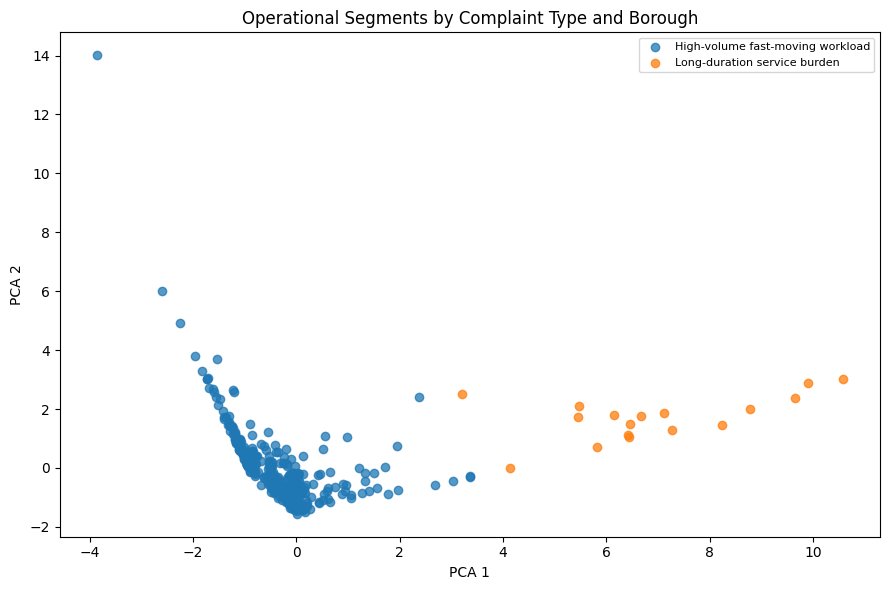

In [ ]:
# PCA SEGMENT PLOT

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
ops_model["pca1"] = coords[:, 0]
ops_model["pca2"] = coords[:, 1]

plt.figure(figsize=(9, 6))
for seg, g in ops_model.groupby("segment_name"):
    plt.scatter(g["pca1"], g["pca2"], label=seg, alpha=0.75)
plt.title("Operational Segments by Complaint Type and Borough")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / "operational_segments_pca.png", dpi=160)
plt.show()


,segment_name,complaint_type,borough,request_count,avg_response_hours,same_day_rate,repeat_proxy_rate
152,High-volume fast-moving workload,ILLEGAL PARKING,BROOKLYN,24380,2.296012,0.904389,0.715094
214,High-volume fast-moving workload,NOISE - RESIDENTIAL,BRONX,22035,15.582719,0.756115,0.884865
154,High-volume fast-moving workload,ILLEGAL PARKING,QUEENS,19794,2.839591,0.834546,0.677175
131,High-volume fast-moving workload,HEAT/HOT WATER,BRONX,14071,42.584119,0.152868,0.889063
215,High-volume fast-moving workload,NOISE - RESIDENTIAL,BROOKLYN,13959,2.022186,0.861666,0.698689
217,High-volume fast-moving workload,NOISE - RESIDENTIAL,QUEENS,10931,8.071521,0.825085,0.651176
132,High-volume fast-moving workload,HEAT/HOT WATER,BROOKLYN,10648,54.109536,0.110819,0.773666
151,High-volume fast-moving workload,ILLEGAL PARKING,BRONX,10166,3.558325,0.851564,0.697029
216,High-volume fast-moving workload,NOISE - RESIDENTIAL,MANHATTAN,10017,1.201189,0.885395,0.796346
25,High-volume fast-moving workload,BLOCKED DRIVEWAY,QUEENS,10013,2.897610,0.8461,0.470888


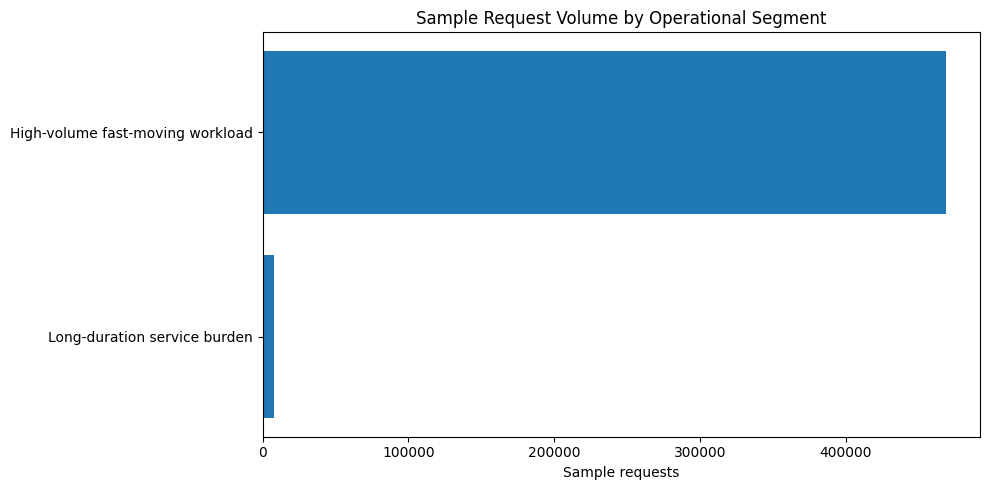

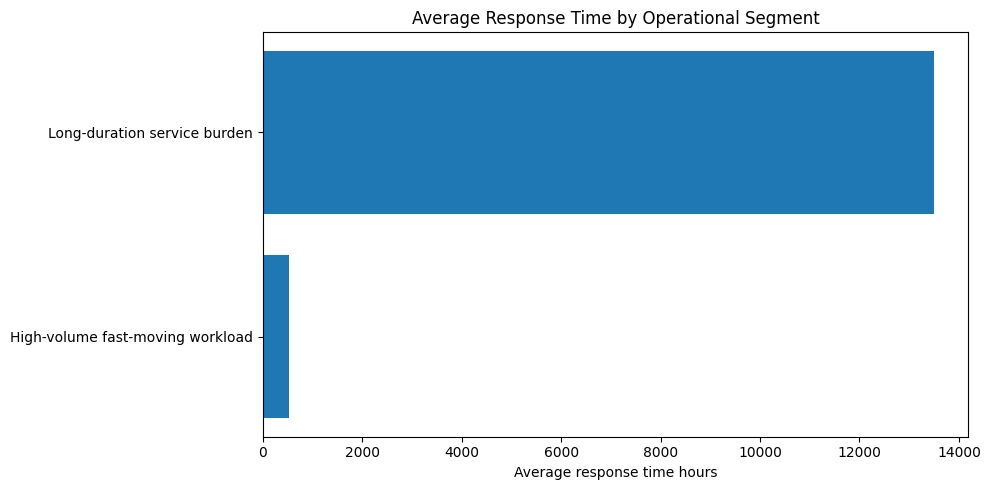

In [ ]:
# REPORT-READY SEGMENT TABLES AND PLOTS

top_units = ops_model.sort_values("request_count", ascending=False).groupby("segment_name").head(10)
top_units.to_csv(OUTPUT_DIR / "top_operational_units_by_segment.csv", index=False)
display(top_units[["segment_name", "complaint_type", "borough", "request_count", "avg_response_hours", "same_day_rate", "repeat_proxy_rate"]])

plot_seg = segment_profile.sort_values("total_sample_requests")
plt.figure(figsize=(10, 5))
plt.barh(plot_seg["segment_name"], plot_seg["total_sample_requests"])
plt.title("Sample Request Volume by Operational Segment")
plt.xlabel("Sample requests")
plt.tight_layout()
plt.savefig(PLOT_DIR / "segment_volume.png", dpi=160)
plt.show()

plot_seg = segment_profile.sort_values("avg_response_hours")
plt.figure(figsize=(10, 5))
plt.barh(plot_seg["segment_name"], plot_seg["avg_response_hours"])
plt.title("Average Response Time by Operational Segment")
plt.xlabel("Average response time hours")
plt.tight_layout()
plt.savefig(PLOT_DIR / "segment_avg_response_time.png", dpi=160)
plt.show()


,borough,incident_zip,complaint_type,request_count,avg_response_hours,repeat_proxy_rate,delay_48h_rate
1664,BRONX,10466,NOISE - RESIDENTIAL,9980,30.828429,0.987375,0.082766
2653,BROOKLYN,11201,ILLEGAL PARKING,1709,1.557242,0.855471,0.000000
14504,QUEENS,11385,ILLEGAL PARKING,1641,3.463510,0.758684,0.000609
11503,QUEENS,11101,ILLEGAL PARKING,1365,1.950024,0.810256,0.000000
5560,BROOKLYN,11226,HEAT/HOT WATER,1304,51.118122,0.907975,0.434816
680,BRONX,10457,HEAT/HOT WATER,1275,41.602494,0.923922,0.345098
791,BRONX,10458,HEAT/HOT WATER,1235,42.462085,0.915789,0.353846
1872,BRONX,10468,HEAT/HOT WATER,1193,41.125634,0.936295,0.341157
1758,BRONX,10467,HEAT/HOT WATER,1152,42.389151,0.896701,0.357639
4101,BROOKLYN,11214,ILLEGAL PARKING,1150,2.351786,0.766957,0.000000


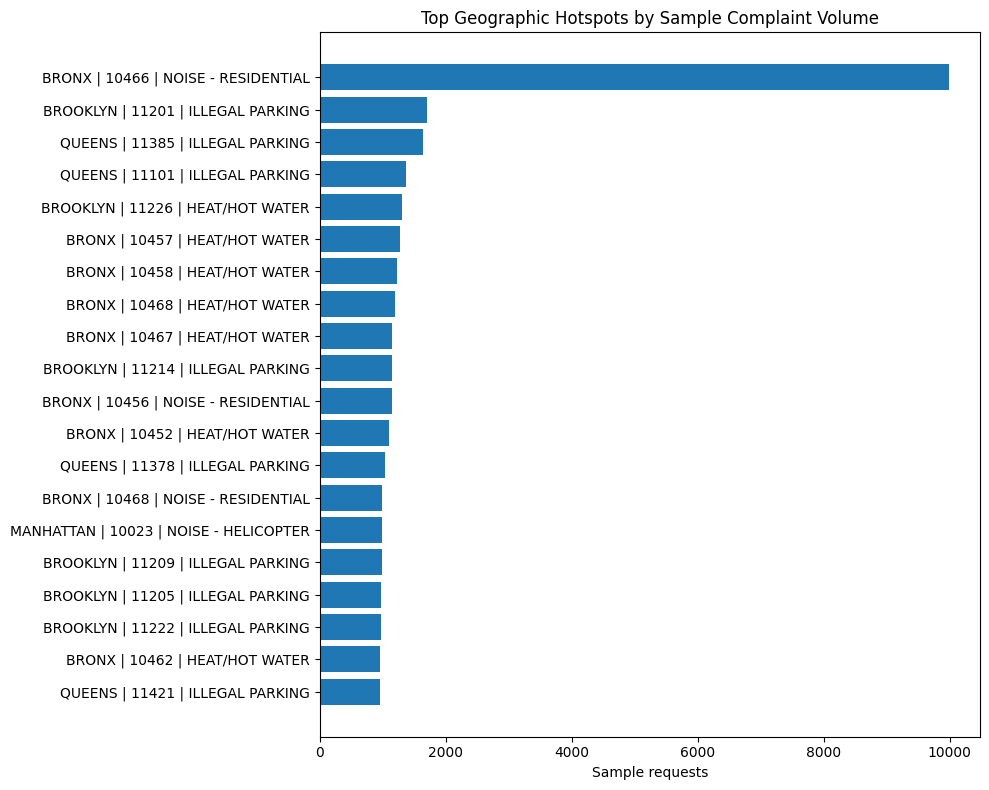

In [ ]:
# GEOGRAPHIC HOTSPOT ANALYSIS
# This is a grouped hotspot summary. It is more stable than trying to interpret every DBSCAN point.

geo_cols = [c for c in ["borough", "incident_zip", "complaint_type"] if c in df_labeled.columns]
hotspots = (
    df_labeled.groupby(geo_cols)
    .agg(
        request_count=("complaint_type", "size"),
        avg_response_hours=("response_time_hours", "mean"),
        repeat_proxy_rate=("repeat_complaint_proxy", "mean"),
        delay_48h_rate=("delay_risk_48h_flag", "mean") if "delay_risk_48h_flag" in df_labeled.columns else ("response_time_hours", lambda s: (s > 48).mean()),
    )
    .reset_index()
    .sort_values("request_count", ascending=False)
)
hotspots.to_csv(OUTPUT_DIR / "geographic_hotspot_summary.csv", index=False)
display(hotspots.head(25))

plt.figure(figsize=(10, 8))
plot_hot = hotspots.head(20).sort_values("request_count")
labels = plot_hot[geo_cols].astype(str).agg(" | ".join, axis=1)
plt.barh(labels, plot_hot["request_count"])
plt.title("Top Geographic Hotspots by Sample Complaint Volume")
plt.xlabel("Sample requests")
plt.tight_layout()
plt.savefig(PLOT_DIR / "top_geographic_hotspots.png", dpi=160)
plt.show()


,created_ym,segment_name,request_count,avg_response_hours,delay_48h_rate,repeat_proxy_rate
0,2020-01,High-volume fast-moving workload,8466,490.314897,0.359083,0.437633
1,2020-01,Long-duration service burden,100,23503.316617,0.790000,0.180000
2,2020-02,High-volume fast-moving workload,4858,359.566999,0.343763,0.402841
3,2020-02,Long-duration service burden,87,27036.055572,0.873563,0.252874
4,2020-03,High-volume fast-moving workload,4018,359.200906,0.347437,0.450971


Trend sample includes 76 months. Seasonal claims are more supportable.


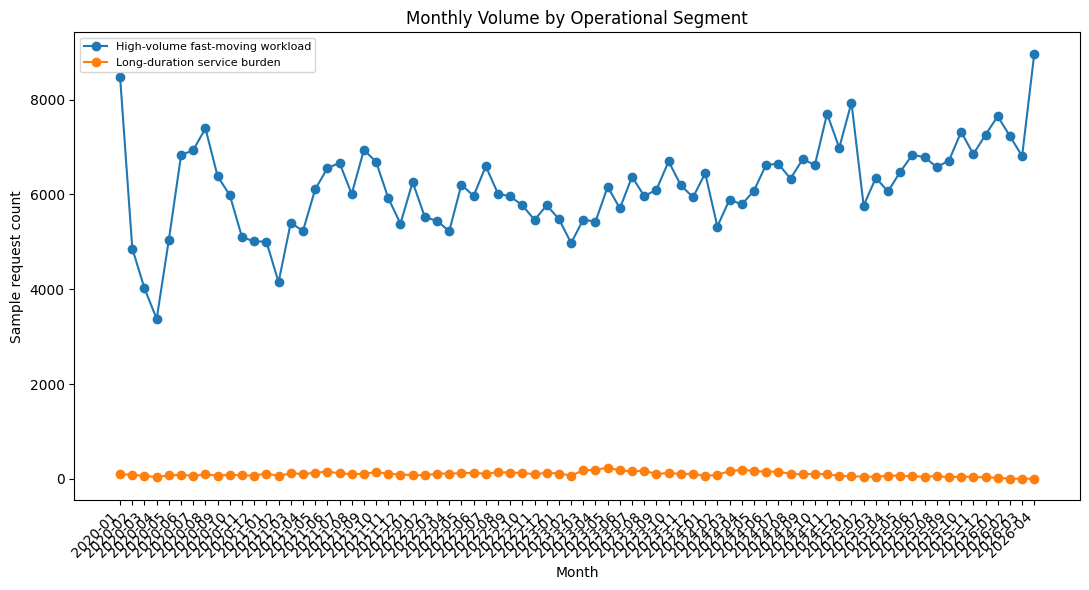

In [ ]:
# TREND ANALYSIS BY SEGMENT

trend = (
    df_labeled.dropna(subset=["segment_name"])
    .groupby(["created_ym", "segment_name"])
    .agg(
        request_count=("complaint_type", "size"),
        avg_response_hours=("response_time_hours", "mean"),
        delay_48h_rate=("delay_risk_48h_flag", "mean") if "delay_risk_48h_flag" in df_labeled.columns else ("response_time_hours", lambda s: (s > 48).mean()),
        repeat_proxy_rate=("repeat_complaint_proxy", "mean"),
    )
    .reset_index()
)
trend.to_csv(OUTPUT_DIR / "monthly_trend_by_operational_segment.csv", index=False)
display(trend.head())

month_count = df_labeled["created_ym"].nunique()
trend_warning = ""
if month_count < 12:
    trend_warning = (
        f"Only {month_count} unique months are present in the sample. "
        "Use trend results cautiously and avoid making strong seasonality claims."
    )
else:
    trend_warning = f"Trend sample includes {month_count} months. Seasonal claims are more supportable."
print(trend_warning)

plt.figure(figsize=(11, 6))
for seg, g in trend.groupby("segment_name"):
    g = g.sort_values("created_ym")
    plt.plot(g["created_ym"], g["request_count"], marker="o", label=seg)
plt.title("Monthly Volume by Operational Segment")
plt.xlabel("Month")
plt.ylabel("Sample request count")
plt.xticks(rotation=45, ha="right")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / "monthly_volume_by_segment.png", dpi=160)
plt.show()


In [ ]:
# MANAGEMENT FINDINGS TABLE

findings = []
for _, row in segment_profile.iterrows():
    findings.append({
        "segment_name": row["segment_name"],
        "sample_requests": int(row["total_sample_requests"]),
        "avg_response_hours": round(row["avg_response_hours"], 2),
        "same_day_rate": round(row["avg_same_day_rate"], 3),
        "repeat_proxy_rate": round(row["avg_repeat_proxy_rate"], 3),
        "management_use": "Use this segment to separate fast-moving high-volume workload from long-duration or recurring operational burden."
    })

management_findings = pd.DataFrame(findings)
management_findings["trend_warning"] = trend_warning
management_findings.to_csv(OUTPUT_DIR / "management_ready_clustering_findings.csv", index=False)
display(management_findings)

# Save labeled records for appendix review or optional downstream use.
df_labeled.to_parquet(OUTPUT_DIR / "model_sample_with_operational_segments_v3.parquet", index=False)
ops_model.to_csv(OUTPUT_DIR / "operational_units_with_segments.csv", index=False)


,segment_name,sample_requests,avg_response_hours,same_day_rate,repeat_proxy_rate,management_use,trend_warning
0,High-volume fast-moving workload,468770,523.97,0.329,0.338,Use this segment to separate fast-moving high-...,Trend sample includes 76 months. Seasonal clai...
1,Long-duration service burden,7501,13507.76,0.004,0.333,Use this segment to separate fast-moving high-...,Trend sample includes 76 months. Seasonal clai...


In [ ]:
# SAVE MANIFEST AND ZIP OUTPUTS

manifest = {
    "run_timestamp": RUN_TS,
    # "input_model_ready_path": str(MODEL_READY_PATH),
    "input_analysis_ready_path": str(ANALYSIS_READY_PATH),
    "output_dir": str(OUTPUT_DIR),
    "selected_k": int(best_k),
    "min_cluster_records_for_report": int(MIN_CLUSTER_RECORDS_FOR_REPORT),
    "unique_months_in_sample": int(month_count),
    "trend_warning": trend_warning,
    "important_note": "Notebook 4 v3 uses corrected repeat proxy and excludes tiny operational units from reportable segment conclusions."
}
with open(OUTPUT_DIR / "notebook4_v3_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))

zip_path = "/content/notebook4_v3_outputs.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)
shutil.make_archive(zip_path.replace(".zip", ""), "zip", OUTPUT_DIR)
print("Created:", zip_path)


{
  "run_timestamp": "20260512_112335",
  "input_analysis_ready_path": "/content/notebook2_v3_outputs_extracted/analysis_ready_sample_v3.parquet",
  "output_dir": "/content/notebook4_v3_outputs",
  "selected_k": 2,
  "min_cluster_records_for_report": 100,
  "unique_months_in_sample": 76,
  "trend_warning": "Trend sample includes 76 months. Seasonal claims are more supportable.",
  "important_note": "Notebook 4 v3 uses corrected repeat proxy and excludes tiny operational units from reportable segment conclusions."
}
Created: /content/notebook4_v3_outputs.zip
